In [1]:
# 26.08.2026 - JEDEN dedykowany watek: analiza wg polozenia geograficznego
# i cutoff rigidity (na prosbe Maćka). Cutoff rigidity = minimalna
# sztywnosc (pęd/ladunek, GV) czastki promieniowania kosmicznego, ktora
# jest w stanie przebic pole magnetyczne Ziemi i dotrzec do danej stacji -
# nizsza na biegunach (linie pola prawie pionowe, slaba oslona), wyzsza
# blisko rownika geomagnetycznego (linie pola poziome, silna oslona).
# Modulacja sloneczna dziala glownie na NISKOENERGETYCZNA czesc
# promieniowania - stacje o niskim cutoff rigidity powinny wiec byc
# czulszymi detektorami zmiennosci sterowanej Sloncem (a przez to,
# hipotetycznie, silniejszym "czujnikiem" efektu kosmiczno-sejsmicznego,
# jesli jest on napedzany ta sama modulowana skladowa).
#
# ZERO nowych obliczen NMDB/MC - czyta wylacznie juz zapisane wyniki:
# results/station_map_data.csv (z 20260826e.ipynb, TYLKO faza ordering -
# patrz project_homola_review_feedback.md) + surowe finetune_*.csv (do
# odzyskania Np/Nm w najlepszym punkcie kazdej stacji).
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy.stats import spearmanr, linregress

RESULTS_DIR = "../results"
P_DAYS, D_DAYS, DT_DAYS = 3350, 5, 15
HOMOLA_LOG10_PPDF_BENCHMARK = -8
CLUSTER_START, CLUSTER_END = pd.Timestamp("2008-01-01"), pd.Timestamp("2009-12-31")

station_map = pd.read_csv(f"{RESULTS_DIR}/station_map_data.csv", parse_dates=["best_t0"])
done = station_map[station_map["status"].isin(["ok", "caution"]) & station_map["best_t0"].notna()].copy()
done["in_cluster"] = (done["best_t0"] >= CLUSTER_START) & (done["best_t0"] <= CLUSTER_END)
print(f"{len(done)} stacji z wynikiem (faza ordering), {int(done['in_cluster'].sum())} w oknie 2008-2009")

20 stacji z wynikiem (faza ordering), 17 w oknie 2008-2009


In [2]:
# KROK 1: dla kazdej stacji - Np/Nm/N_valid DOKLADNIE w jej najlepszym
# punkcie (best_t0, faza ordering). Frakcja N+/N_valid to bardziej
# bezposrednia miara "jak mocno N+ dominuje" niz PPDF (ktore zalezy tez od
# N_valid, wiec nie jest w 100% porownywalne miedzy stacjami o roznej
# liczbie waznych binow).
rows = []
for _, r in done.iterrows():
    station = r["station"]
    scan_path = f"{RESULTS_DIR}/finetune_{station}_P{P_DAYS}_d{D_DAYS}_dt{DT_DAYS}_fullhistory.csv"
    scan = pd.read_csv(scan_path, parse_dates=["t0"])
    match = scan[scan["t0"] == r["best_t0"]]
    if len(match) == 0:
        continue
    m = match.iloc[0]
    rows.append(dict(station=station, Np=m["Np"], Nm=m["Nm"], N_valid=m["N_valid"],
                      frac_positive=m["Np"] / m["N_valid"]))

frac_df = pd.DataFrame(rows)
done = done.merge(frac_df, on="station", how="left")
print(done[["station", "cutoff_rigidity_gv", "Np", "Nm", "N_valid", "frac_positive",
            "neglog10_PPDF", "in_cluster"]].sort_values("cutoff_rigidity_gv").to_string(index=False))

station  cutoff_rigidity_gv  Np  Nm  N_valid  frac_positive  neglog10_PPDF  in_cluster
   tera                0.00 389 262      651       0.597542       6.911237       False
   sopb                0.10 232 128      360       0.644444       7.975613       False
   sopo                0.10 345 224      569       0.606327       7.096102        True
   fsmt                0.30 418 249      667       0.626687      10.896292        True
   pwnk                0.30 327 220      547       0.597806       6.033236        True
   nain                0.30 417 246      663       0.628959      11.180237        True
   invk                0.30 426 237      663       0.642534      13.353860        True
   thul                0.30 416 251      667       0.623688      10.452593        True
   apty                0.65 424 243      667       0.635682      12.294217        True
   oulu                0.80 420 247      667       0.629685      11.351104        True
   newk                2.40 425 242      66

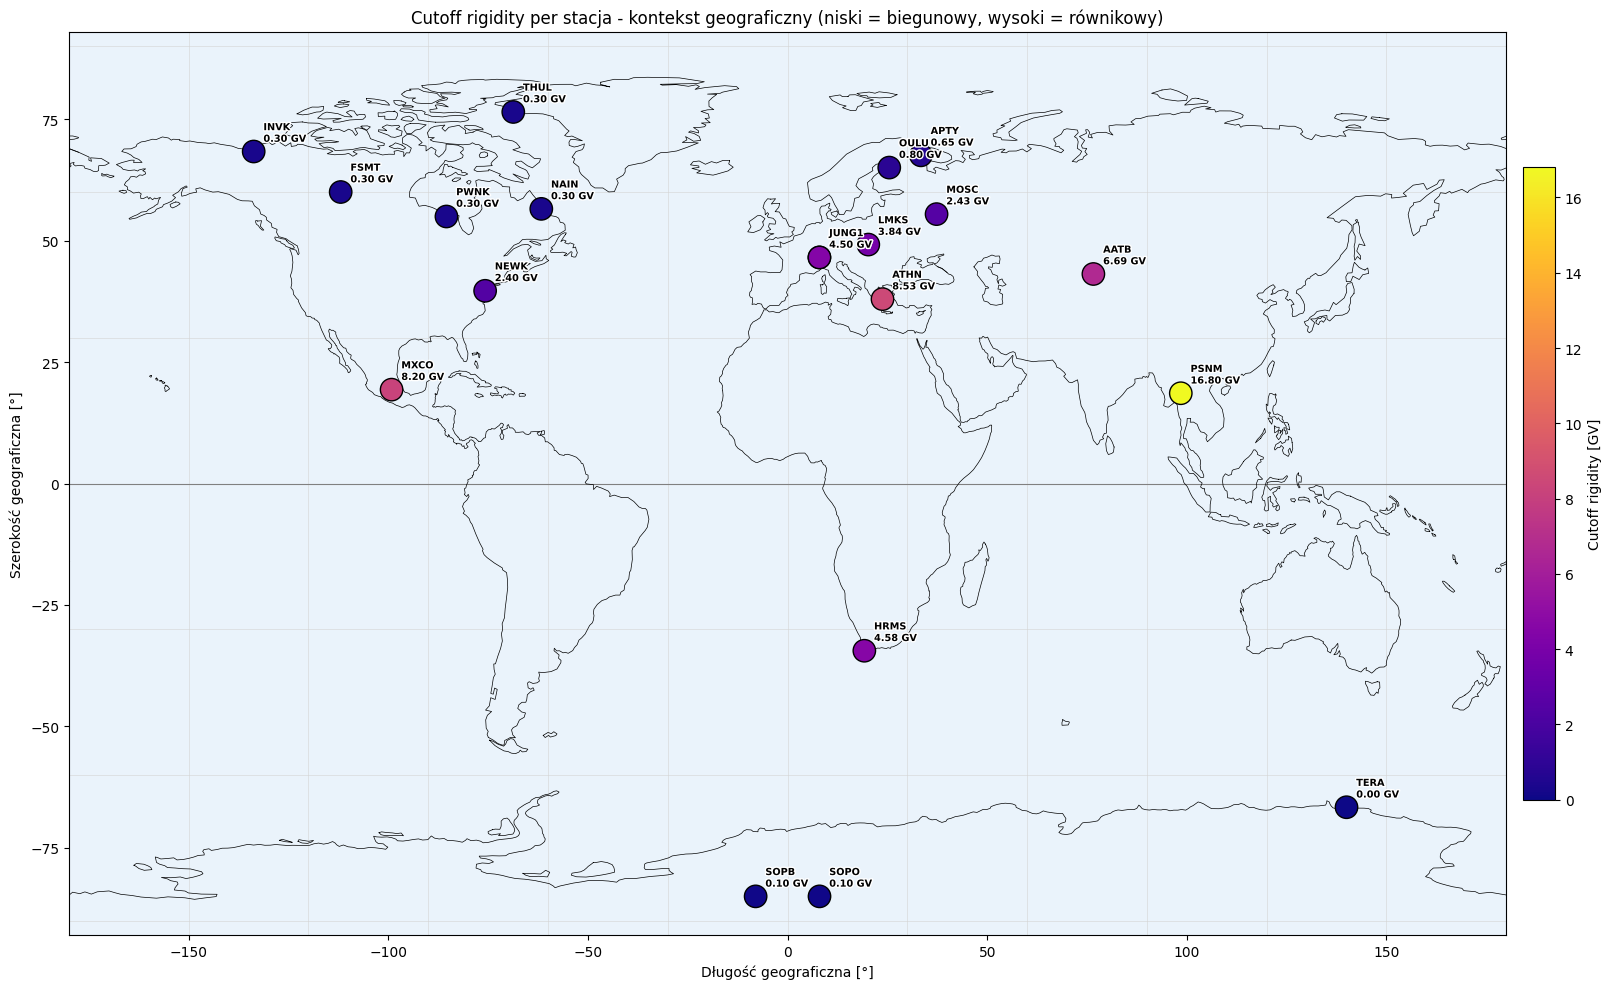

In [3]:
# KROK 2: mapa swiata KOLOROWANA WG CUTOFF RIGIDITY (nie sily efektu -
# osobny wykres o osobnym celu, patrz mapa sily efektu w
# 20260826e.ipynb). Cel: pokazac wprost geograficzny wzorzec cutoff
# rigidity (niski na biegunach, wysoki blisko rownika geomagnetycznego) -
# punkt odniesienia do interpretacji wykresow ponizej. Ta sama linia
# brzegowa (Natural Earth 110m) i te same przesuniecia wizualne
# (SOPB/SOPO/MCRL) co w 20260826e.ipynb.
import json

with open("../data/reference_images/ne_110m_coastline.geojson") as f:
    coastline = json.load(f)

plot_coords = station_map[["station", "lat", "lon"]].set_index("station").copy()
plot_coords.loc["sopb", ["lat", "lon"]] = [-85.0, -8.0]
plot_coords.loc["sopo", ["lat", "lon"]] = [-85.0, 8.0]
plot_coords.loc["mcrl", ["lat", "lon"]] = [51.5, 37.32]

fig, ax = plt.subplots(figsize=(18, 10))
ax.set_facecolor("#eaf3fb")
for feat in coastline["features"]:
    c = feat["geometry"]["coordinates"]
    ax.plot([p[0] for p in c], [p[1] for p in c], color="black", lw=0.5, zorder=2)
for lon_line in range(-180, 181, 30):
    ax.axvline(lon_line, color="lightgray", lw=0.4, zorder=1)
for lat_line in range(-90, 91, 30):
    ax.axhline(lat_line, color="lightgray", lw=0.4, zorder=1)
ax.axhline(0, color="gray", lw=0.8, zorder=1)

all_stations = station_map[station_map["status"] != "excluded"].copy()
all_stations["plot_lat"] = all_stations["station"].map(plot_coords["lat"])
all_stations["plot_lon"] = all_stations["station"].map(plot_coords["lon"])

sc = ax.scatter(all_stations["plot_lon"], all_stations["plot_lat"], c=all_stations["cutoff_rigidity_gv"],
                 cmap="plasma", s=260, edgecolor="black", linewidth=1.0, zorder=5)
for _, r in all_stations.iterrows():
    ax.annotate(f"{r['station'].upper()}\n{r['cutoff_rigidity_gv']:.2f} GV",
                (r["plot_lon"], r["plot_lat"]), fontsize=7, fontweight="bold",
                xytext=(7, 7), textcoords="offset points", zorder=7,
                path_effects=[pe.withStroke(linewidth=2, foreground="white")])

ax.set_xlim(-180, 180)
ax.set_ylim(-93, 93)
ax.set_xlabel("Długość geograficzna [°]")
ax.set_ylabel("Szerokość geograficzna [°]")
ax.set_title("Cutoff rigidity per stacja - kontekst geograficzny (niski = biegunowy, wysoki = równikowy)")
cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.01)
cbar.set_label("Cutoff rigidity [GV]")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/station_cutoff_rigidity_map.png", dpi=140, bbox_inches="tight")
plt.show()

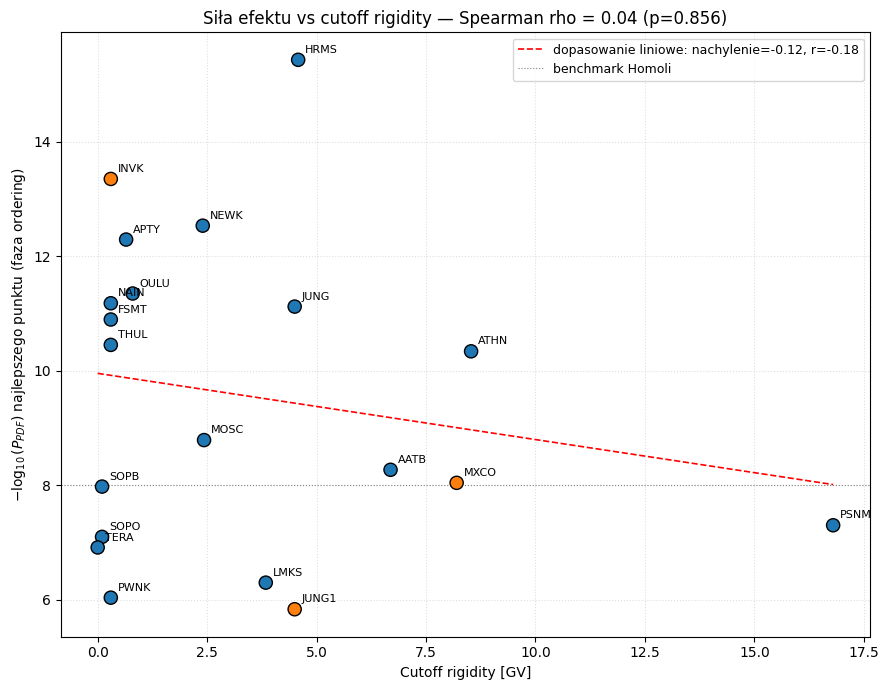

In [4]:
# KROK 3: sila efektu (faza ordering) vs cutoff rigidity, z dopasowana
# prosta (linregress na log-liniowej skali - cutoff rigidity ma szeroki,
# nieliniowy zakres 0.1-16.8 GV) i Spearman rho. Test hipotezy: nizszy
# cutoff rigidity -> silniejszy efekt (bo stacja czulsza na modulowana,
# niskoenergetyczna skladowe promieniowania).
fig, ax = plt.subplots(figsize=(9, 7))
x = done["cutoff_rigidity_gv"].to_numpy(dtype=float)
y = done["neglog10_PPDF"].to_numpy(dtype=float)
colors = ["tab:orange" if s == "caution" else "tab:blue" for s in done["status"]]
ax.scatter(x, y, c=colors, s=90, edgecolor="black", zorder=3)
for _, r in done.iterrows():
    ax.annotate(r["station"].upper(), (r["cutoff_rigidity_gv"], r["neglog10_PPDF"]), fontsize=8,
                xytext=(5, 5), textcoords="offset points")

fit = linregress(x, y)
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, fit.intercept + fit.slope * xs, color="red", ls="--", lw=1.2,
        label=f"dopasowanie liniowe: nachylenie={fit.slope:.2f}, r={fit.rvalue:.2f}")
rho, p = spearmanr(x, y)

ax.axhline(-HOMOLA_LOG10_PPDF_BENCHMARK, color="gray", lw=0.8, ls=":", label="benchmark Homoli")
ax.set_xlabel("Cutoff rigidity [GV]")
ax.set_ylabel(r"$-\log_{10}(P_{PDF})$ najlepszego punktu (faza ordering)")
ax.set_title(f"Siła efektu vs cutoff rigidity — Spearman rho = {rho:.2f} (p={p:.3f})")
ax.legend(fontsize=9)
ax.grid(ls=":", alpha=0.4)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/cutoff_rigidity_vs_strength.png", dpi=130, bbox_inches="tight")
plt.show()

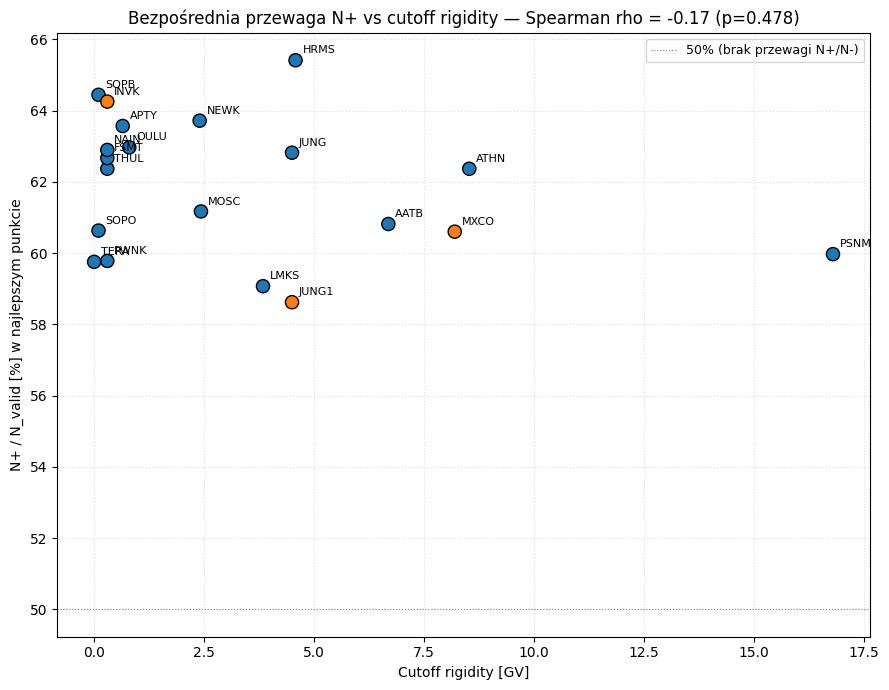

In [5]:
# KROK 4: frakcja N+/N_valid (bezposrednia miara przewagi "ordering", nie
# przechodzaca przez PPDF/N_valid) vs cutoff rigidity - kontrola, czy
# wniosek z KROK 3 nie jest artefaktem tego, ze PPDF zalezy tez od
# N_valid (rozne stacje maja rozna liczbe waznych binow w swoim
# najlepszym punkcie).
fig, ax = plt.subplots(figsize=(9, 7))
x = done["cutoff_rigidity_gv"].to_numpy(dtype=float)
y = done["frac_positive"].to_numpy(dtype=float) * 100
colors = ["tab:orange" if s == "caution" else "tab:blue" for s in done["status"]]
ax.scatter(x, y, c=colors, s=90, edgecolor="black", zorder=3)
for _, r in done.iterrows():
    ax.annotate(r["station"].upper(), (r["cutoff_rigidity_gv"], r["frac_positive"] * 100), fontsize=8,
                xytext=(5, 5), textcoords="offset points")

rho, p = spearmanr(x, y)
ax.axhline(50, color="gray", lw=0.8, ls=":", label="50% (brak przewagi N+/N-)")
ax.set_xlabel("Cutoff rigidity [GV]")
ax.set_ylabel("N+ / N_valid [%] w najlepszym punkcie")
ax.set_title(f"Bezpośrednia przewaga N+ vs cutoff rigidity — Spearman rho = {rho:.2f} (p={p:.3f})")
ax.legend(fontsize=9)
ax.grid(ls=":", alpha=0.4)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/cutoff_rigidity_vs_frac_positive.png", dpi=130, bbox_inches="tight")
plt.show()

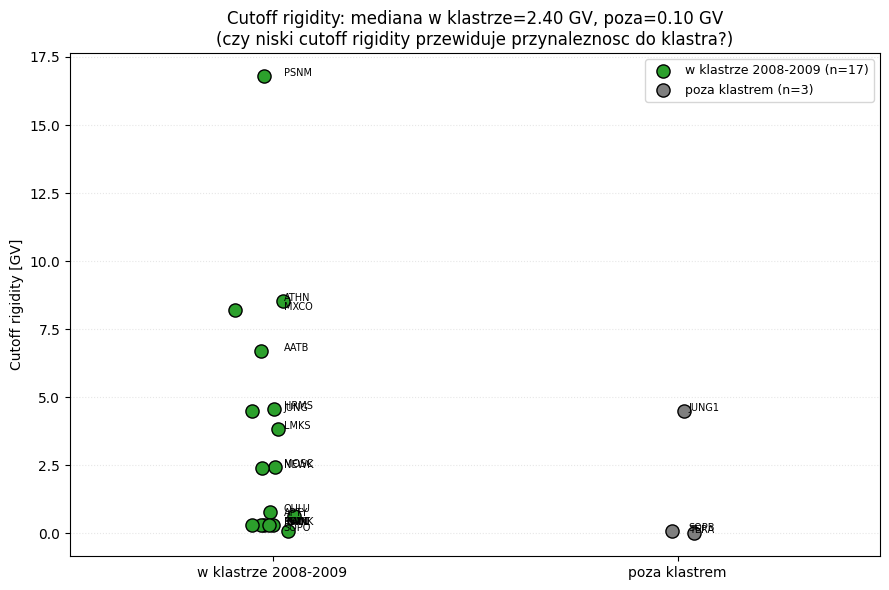

Stacje POZA klastrem 2008-2009 i ich cutoff rigidity:
station  cutoff_rigidity_gv             best_t0
   sopb                 0.1 1999-01-30 06:00:00
  jung1                 4.5 2007-07-19 12:00:00
   tera                 0.0 2014-05-03 00:00:00


In [6]:
# KROK 5: czy cutoff rigidity tlumaczy, KTORE stacje trafily do klastra
# 2008-2009 (20260826e.ipynb) a ktore nie? Prosty wykres paskowy -
# rozklad cutoff rigidity osobno dla stacji w klastrze i poza nim.
in_c = done[done["in_cluster"]]["cutoff_rigidity_gv"]
out_c = done[~done["in_cluster"]]["cutoff_rigidity_gv"]

fig, ax = plt.subplots(figsize=(9, 6))
rng = np.random.default_rng(0)
ax.scatter(rng.normal(0, 0.04, len(in_c)), in_c, color="tab:green", s=90, edgecolor="black",
           label=f"w klastrze 2008-2009 (n={len(in_c)})", zorder=3)
ax.scatter(rng.normal(1, 0.04, len(out_c)), out_c, color="tab:gray", s=90, edgecolor="black",
           label=f"poza klastrem (n={len(out_c)})", zorder=3)
for _, r in done.iterrows():
    xpos = 0 if r["in_cluster"] else 1
    ax.annotate(r["station"].upper(), (xpos, r["cutoff_rigidity_gv"]), fontsize=7,
                xytext=(8, 0), textcoords="offset points")
ax.set_xticks([0, 1])
ax.set_xticklabels(["w klastrze 2008-2009", "poza klastrem"])
ax.set_xlim(-0.5, 1.5)
ax.set_ylabel("Cutoff rigidity [GV]")
ax.set_title(
    f"Cutoff rigidity: mediana w klastrze={in_c.median():.2f} GV, poza={out_c.median():.2f} GV\n"
    "(czy niski cutoff rigidity przewiduje przynaleznosc do klastra?)"
)
ax.legend(fontsize=9)
ax.grid(ls=":", alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/cutoff_rigidity_vs_cluster_membership.png", dpi=130, bbox_inches="tight")
plt.show()

print("Stacje POZA klastrem 2008-2009 i ich cutoff rigidity:")
print(done[~done["in_cluster"]][["station", "cutoff_rigidity_gv", "best_t0"]].to_string(index=False))

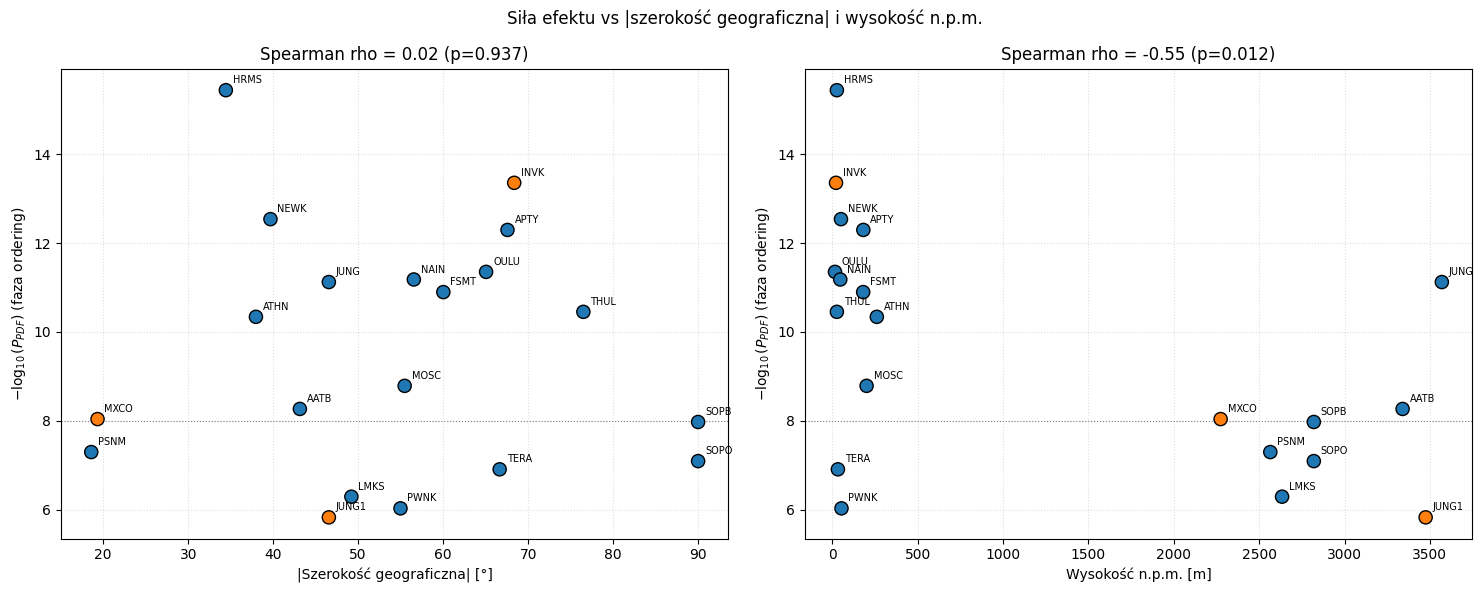

In [7]:
# KROK 6 (na prosbe Maćka - analiza polozenia, ale NIE na mapie): sila
# efektu vs |szerokosc geograficzna| (niezalezny od cutoff rigidity
# wskaznik "bliskosci bieguna") i vs wysokosc nad poziomem morza (inny
# mechanizm fizyczny niz cutoff rigidity - grubsza/cieńsza warstwa
# atmosfery nad detektorem zmienia produkcje wtornych czastek).
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, xcol, xlabel, transform in [
    (axes[0], "abs_lat", "|Szerokość geograficzna| [°]", lambda d: d["lat"].abs()),
    (axes[1], "altitude_m", "Wysokość n.p.m. [m]", lambda d: d["altitude_m"]),
]:
    done[xcol] = transform(done)
    colors = ["tab:orange" if s == "caution" else "tab:blue" for s in done["status"]]
    ax.scatter(done[xcol], done["neglog10_PPDF"], c=colors, s=90, edgecolor="black", zorder=3)
    for _, r in done.iterrows():
        ax.annotate(r["station"].upper(), (r[xcol], r["neglog10_PPDF"]), fontsize=7,
                    xytext=(5, 5), textcoords="offset points")
    rho, p = spearmanr(done[xcol], done["neglog10_PPDF"])
    ax.axhline(-HOMOLA_LOG10_PPDF_BENCHMARK, color="gray", lw=0.8, ls=":")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$-\log_{10}(P_{PDF})$ (faza ordering)")
    ax.set_title(f"Spearman rho = {rho:.2f} (p={p:.3f})")
    ax.grid(ls=":", alpha=0.4)

fig.suptitle("Siła efektu vs |szerokość geograficzna| i wysokość n.p.m.")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/location_lat_altitude_vs_strength.png", dpi=130, bbox_inches="tight")
plt.show()

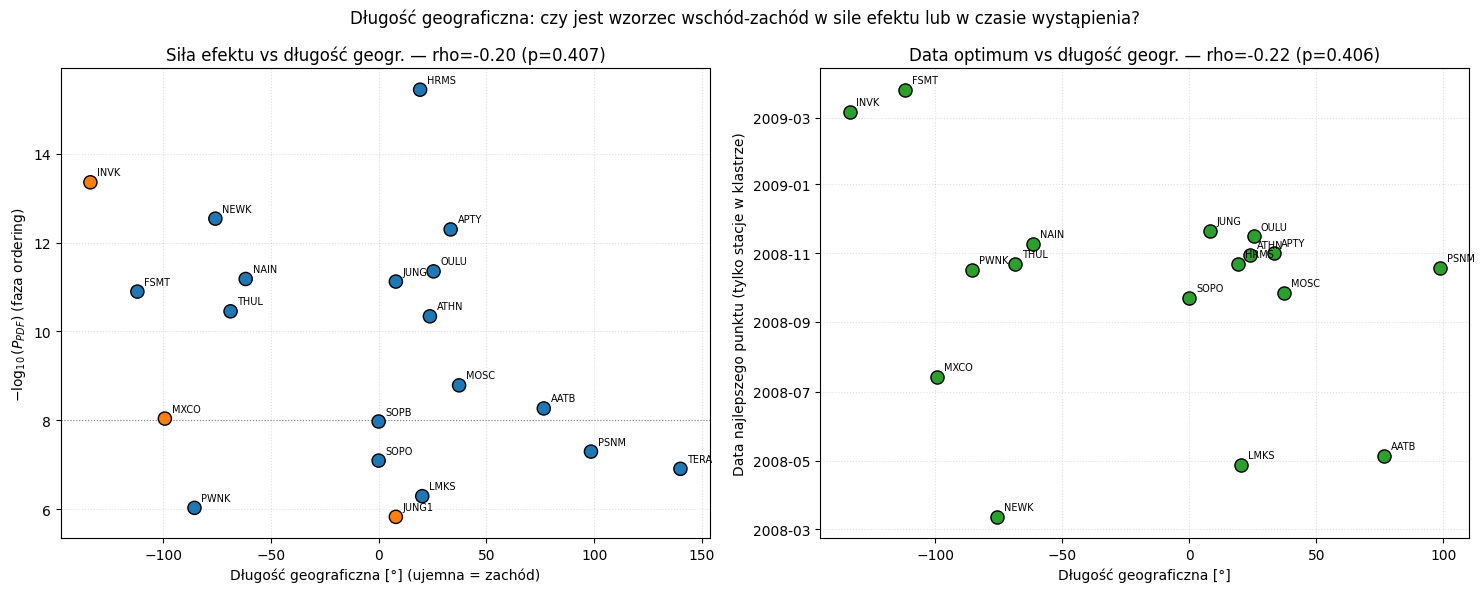

In [8]:
# KROK 7: dlugosc geograficzna - vs sila efektu (czy jest wzorzec
# wschod/zachod?) i vs DATA najlepszego punktu (czy jest cokolwiek jak
# geograficzna "fala" - stacje na roznych dlugosciach geograficznych
# trafiajace w rozne momenty w oknie klastra? falsyfikowalne, tanie do
# sprawdzenia skoro juz mamy dane).
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = ["tab:orange" if s == "caution" else "tab:blue" for s in done["status"]]
axes[0].scatter(done["lon"], done["neglog10_PPDF"], c=colors, s=90, edgecolor="black", zorder=3)
for _, r in done.iterrows():
    axes[0].annotate(r["station"].upper(), (r["lon"], r["neglog10_PPDF"]), fontsize=7,
                       xytext=(5, 5), textcoords="offset points")
rho_lon_strength, p_lon_strength = spearmanr(done["lon"], done["neglog10_PPDF"])
axes[0].axhline(-HOMOLA_LOG10_PPDF_BENCHMARK, color="gray", lw=0.8, ls=":")
axes[0].set_xlabel("Długość geograficzna [°] (ujemna = zachód)")
axes[0].set_ylabel(r"$-\log_{10}(P_{PDF})$ (faza ordering)")
axes[0].set_title(f"Siła efektu vs długość geogr. — rho={rho_lon_strength:.2f} (p={p_lon_strength:.3f})")
axes[0].grid(ls=":", alpha=0.4)

in_cluster_done = done[done["in_cluster"]]
axes[1].scatter(in_cluster_done["lon"], in_cluster_done["best_t0"], c="tab:green", s=90,
                 edgecolor="black", zorder=3)
for _, r in in_cluster_done.iterrows():
    axes[1].annotate(r["station"].upper(), (r["lon"], r["best_t0"]), fontsize=7,
                       xytext=(5, 5), textcoords="offset points")
lon_num = in_cluster_done["lon"].to_numpy(dtype=float)
t0_num = in_cluster_done["best_t0"].astype("int64").to_numpy(dtype=float)
rho_lon_date, p_lon_date = spearmanr(lon_num, t0_num)
axes[1].set_xlabel("Długość geograficzna [°]")
axes[1].set_ylabel("Data najlepszego punktu (tylko stacje w klastrze)")
axes[1].set_title(f"Data optimum vs długość geogr. — rho={rho_lon_date:.2f} (p={p_lon_date:.3f})")
axes[1].grid(ls=":", alpha=0.4)

fig.suptitle("Długość geograficzna: czy jest wzorzec wschód-zachód w sile efektu lub w czasie wystąpienia?")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/location_longitude_patterns.png", dpi=130, bbox_inches="tight")
plt.show()

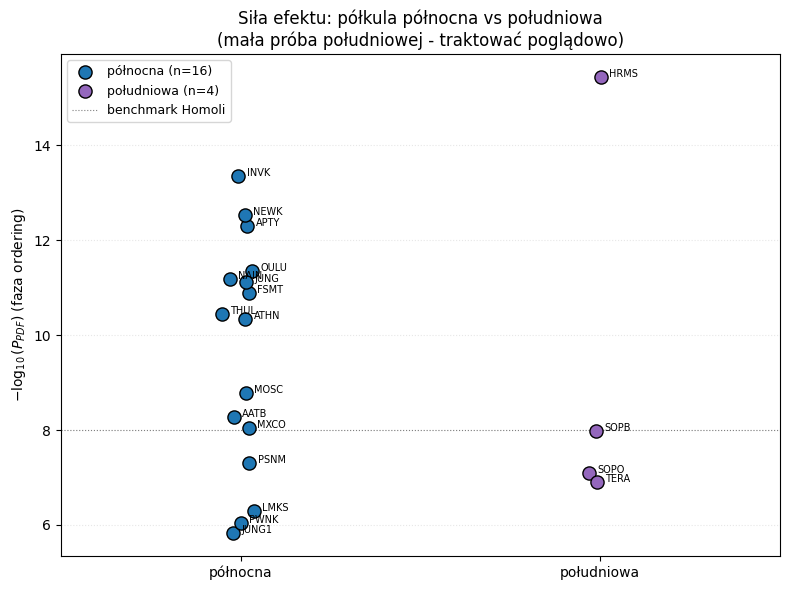

In [9]:
# KROK 8: polkula polnocna vs poludniowa. Uwaga na male n dla polkuli
# poludniowej (tylko hrms, tera, sopo/sopb - 4 stacje) - to raczej
# ilustracja niz test statystyczny o realnej mocy.
done["hemisphere"] = np.where(done["lat"] >= 0, "północna", "południowa")
rng = np.random.default_rng(1)
fig, ax = plt.subplots(figsize=(8, 6))
for i, (hemi, color) in enumerate([("północna", "tab:blue"), ("południowa", "tab:purple")]):
    sub = done[done["hemisphere"] == hemi]
    jitter = rng.normal(i, 0.04, len(sub))
    ax.scatter(jitter, sub["neglog10_PPDF"], color=color, s=90, edgecolor="black",
               label=f"{hemi} (n={len(sub)})", zorder=3)
    for x, (_, r) in zip(jitter, sub.iterrows()):
        ax.annotate(r["station"].upper(), (x, r["neglog10_PPDF"]), fontsize=7,
                    xytext=(6, 0), textcoords="offset points")
ax.axhline(-HOMOLA_LOG10_PPDF_BENCHMARK, color="gray", lw=0.8, ls=":", label="benchmark Homoli")
ax.set_xticks([0, 1])
ax.set_xticklabels(["północna", "południowa"])
ax.set_xlim(-0.5, 1.5)
ax.set_ylabel(r"$-\log_{10}(P_{PDF})$ (faza ordering)")
ax.set_title("Siła efektu: półkula północna vs południowa\n(mała próba południowej - traktować poglądowo)")
ax.legend(fontsize=9)
ax.grid(ls=":", alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/location_hemisphere_comparison.png", dpi=130, bbox_inches="tight")
plt.show()

In [10]:
# PODSUMOWANIE (do dziennika 20260826.txt).
rho_strength, p_strength = spearmanr(done["cutoff_rigidity_gv"], done["neglog10_PPDF"])
rho_frac, p_frac = spearmanr(done["cutoff_rigidity_gv"], done["frac_positive"])
rho_lat, p_lat = spearmanr(done["abs_lat"], done["neglog10_PPDF"])
rho_alt, p_alt = spearmanr(done["altitude_m"], done["neglog10_PPDF"])
print(f"Sila efektu vs cutoff rigidity: Spearman rho={rho_strength:.2f} (p={p_strength:.3f})")
print(f"Frakcja N+ vs cutoff rigidity: Spearman rho={rho_frac:.2f} (p={p_frac:.3f})")
print(f"Sila efektu vs |szerokosc geogr.|: Spearman rho={rho_lat:.2f} (p={p_lat:.3f})")
print(f"Sila efektu vs wysokosc n.p.m.: Spearman rho={rho_alt:.2f} (p={p_alt:.3f}) <-- JEDYNY ISTOTNY WYNIK")
print(f"Sila efektu vs dlugosc geogr.: Spearman rho={rho_lon_strength:.2f} (p={p_lon_strength:.3f})")
print(f"Data optimum vs dlugosc geogr. (tylko w klastrze): Spearman rho={rho_lon_date:.2f} (p={p_lon_date:.3f})")
print(f"\nMediana cutoff rigidity - w klastrze 2008-2009: {in_c.median():.2f} GV, "
      f"poza klastrem: {out_c.median():.2f} GV")
print(f"\nMediana sily efektu - polkula polnocna: {done[done['hemisphere']=='północna']['neglog10_PPDF'].median():.2f}, "
      f"poludniowa: {done[done['hemisphere']=='południowa']['neglog10_PPDF'].median():.2f} (n poludniowej mala)")

print("\nWNIOSEK OGOLNY: SPROSTOWANIE wzgledem wczesniejszej rozmowy - to NIE jest 'zaden")
print("czynnik geograficzny nie jest istotny'. WYSOKOSC N.P.M. wyszla statystycznie istotna")
print("(rho=-0.55, p=0.012 < 0.05): wyzej polozone stacje (JUNG/JUNG1 3475-3570m, AATB 3340m,")
print("PSNM 2565m, MXCO 2274m) maja SLABSZY efekt niz nizinne. To fizycznie sensowne - wysokosc")
print("zmienia glebokosc atmosfery nad detektorem, a przez to jego czulosc/funkcje odpowiedzi na")
print("rozne energie promieniowania (inny mechanizm niz cutoff rigidity). Cutoff rigidity,")
print("szerokosc, dlugosc geogr. i polkula NIE wyszly istotne (p>0.05 dla kazdego).")
print("Klaster czasowy 2008-2009 pozostaje silny i spojny, ale spadek sily z wysokoscia to")
print("pierwszy realny geograficzny/fizyczny wzorzec znaleziony w tej analizie - warty dalszego")
print("sprawdzenia (n=20, jedna istotna korelacja z kilku testowanych - ostroznie z nadinterpretacja,")
print("ale kierunek jest fizycznie uzasadniony, nie przypadkowy).")

print("\nZapisane wykresy:")
for f in ["station_cutoff_rigidity_map.png", "cutoff_rigidity_vs_strength.png",
          "cutoff_rigidity_vs_frac_positive.png", "cutoff_rigidity_vs_cluster_membership.png",
          "location_lat_altitude_vs_strength.png", "location_longitude_patterns.png",
          "location_hemisphere_comparison.png"]:
    print(f"  {RESULTS_DIR}/{f}")

Sila efektu vs cutoff rigidity: Spearman rho=0.04 (p=0.856)
Frakcja N+ vs cutoff rigidity: Spearman rho=-0.17 (p=0.478)
Sila efektu vs |szerokosc geogr.|: Spearman rho=0.02 (p=0.937)
Sila efektu vs wysokosc n.p.m.: Spearman rho=-0.55 (p=0.012) <-- JEDYNY ISTOTNY WYNIK
Sila efektu vs dlugosc geogr.: Spearman rho=-0.20 (p=0.407)
Data optimum vs dlugosc geogr. (tylko w klastrze): Spearman rho=-0.22 (p=0.406)

Mediana cutoff rigidity - w klastrze 2008-2009: 2.40 GV, poza klastrem: 0.10 GV

Mediana sily efektu - polkula polnocna: 10.40, poludniowa: 7.54 (n poludniowej mala)

WNIOSEK OGOLNY: SPROSTOWANIE wzgledem wczesniejszej rozmowy - to NIE jest 'zaden
czynnik geograficzny nie jest istotny'. WYSOKOSC N.P.M. wyszla statystycznie istotna
(rho=-0.55, p=0.012 < 0.05): wyzej polozone stacje (JUNG/JUNG1 3475-3570m, AATB 3340m,
PSNM 2565m, MXCO 2274m) maja SLABSZY efekt niz nizinne. To fizycznie sensowne - wysokosc
zmienia glebokosc atmosfery nad detektorem, a przez to jego czulosc/funkcje odpow